# Melanoma Classification Using the Composite DermoscopyDataset

This notebook walks through the full PyHealth pipeline for binary melanoma classification using dermoscopic images.
It combines three publicly available datasets — **ISIC 2018**, **HAM10000**, and **PH2** — into a single composite
dataset via the `DermoscopyDataset` class.

A key feature of this integration is **mode-based image processing** using the `DermoscopyImageProcessor`.
Instead of always passing the raw image to the model, you can choose to feed:
- `whole` — the full dermoscopic image
- `lesion` — only the lesion region (background zeroed out using the segmentation mask)
- `background` — only the surrounding skin (lesion zeroed out)

This is useful for understanding whether a model is relying on the actual lesion or on background artifacts
(e.g., rulers, gel bubbles, dark corners), which is a key question in the paper this repo accompanies.

---

## Step 0: Install PyHealth

In [1]:
%pip install ipywidgets pyhealth openpyxl

Note: you may need to restart the kernel to use updated packages.


## Step 0a: Colab Setup

This cell clones the `derm_set` branch of the PyHealth repo and installs it in editable mode,
so any changes you make to the source take effect immediately without reinstalling.

**Persistent data (recommended):** Mounting Google Drive lets you keep the downloaded datasets
across Colab sessions so you do not have to re-download them each time.

> Skip the Drive mount block if you are running locally — the data paths in Step 1 will point
> to your local folder instead.

In [2]:
import os

# ── Option A: running in Google Colab ─────────────────────────────────────────
IN_COLAB = 'google.colab' in str(get_ipython().extension_manager.loaded)

if IN_COLAB:
    # 1. Mount Google Drive for persistent dataset storage
    from google.colab import drive
    drive.mount('/content/drive')

    # 2. Clone the derm_set branch (skip if already cloned)
    if not os.path.exists('/content/PyHealth'):
        !git clone -b derm_set https://github.com/deadlywrong/PyHealth.git /content/PyHealth

    # 3. Install in editable mode so local edits take effect immediately
    !pip install -e /content/PyHealth --quiet

    PYHEALTH_ROOT = '/content/PyHealth'
    # Dataset root inside Google Drive — change the subfolder name as needed
    DRIVE_DATA_ROOT = '/content/drive/MyDrive/dermoscopy_data'
    os.makedirs(DRIVE_DATA_ROOT, exist_ok=True)

# ── Option B: running locally ──────────────────────────────────────────────────
else:
    # Install from the local clone (editable)
    import subprocess, sys
    repo_dir = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', repo_dir, '--quiet'], check=True)
    PYHEALTH_ROOT = repo_dir
    DRIVE_DATA_ROOT = None   # will use LOCAL_DATA_ROOT in Step 1

print('Setup complete.')
print(f'PyHealth root : {PYHEALTH_ROOT}')
if DRIVE_DATA_ROOT:
    print(f'Drive data root: {DRIVE_DATA_ROOT}')

Setup complete.
PyHealth root : /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/PyHealth


## Step 1: Configure Data Paths

**Please rename and restructure data in folder `dermoscopy_data/` like this:**
```
dermoscopy_data/
├── dermoscopy-metadata-pyhealth.csv  # ← generated by prepare_metadata()
├── ham10000/
│   ├── images/                     # ISIC_*.jpg  (10 015 files)
│   ├── masks/                      # ISIC_*_segmentation.png  (10 015 files)
│   └── images/metadata.csv         # raw — columns: isic_id, diagnosis_1, ...
├── isic2018/
│   ├── images/                     # ISIC_*.jpg  (2 594 files)
│   ├── masks/                      # ISIC_*_segmentation.png  (2 594 files)
│   └── images/metadata.csv         # raw — columns: isic_id, diagnosis_1, ...
└── ph2/
    ├── PH2 Dataset images/         # original nested BMP structure
    │   ├── IMD002/
    │   │   ├── IMD002_Dermoscopic_Image/IMD002.bmp
    │   │   └── IMD002_lesion/IMD002_lesion.bmp
    │   └── ...
    └── PH2_dataset.txt             # raw pipe-delimited metadata

```

**Label encoding:**

| Dataset | Raw label column | Values | Binary mapping |
|---------|-----------------|--------|----------------|
| HAM10000 | `diagnosis_1` | `'Malignant'` / `'Benign'` / `'Indeterminate'` | Malignant→1, Benign→0, Indeterminate dropped |
| ISIC 2018 | `diagnosis_1` | `'Malignant'` / `'Benign'` / `'Indeterminate'` | Malignant→1, Benign→0, Indeterminate dropped |
| PH2 | `Clinical Diagnosis` in `.txt` | `0` (benign) / `1` (atypical) / `2` (melanoma) | 2→1, 0 or 1→0 |

In [3]:
import torch
import os
import pandas as pd

# ── Set your dataset root here ────────────────────────────────────────────────
# Colab users: set this to DRIVE_DATA_ROOT (defined in Step 0a)
# Local users: set this to the absolute path of your dermoscopy_data folder
#   e.g. "/Users/yourname/Documents/.../dermoscopy_data"
DATA_ROOT = DRIVE_DATA_ROOT if (DRIVE_DATA_ROOT and os.path.isdir(DRIVE_DATA_ROOT)) \
            else "/Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data"
# ─────────────────────────────────────────────────────────────────────────────

print(f"DATA_ROOT = {DATA_ROOT}")
assert os.path.isdir(DATA_ROOT), f"DATA_ROOT not found: {DATA_ROOT}"

# Processing mode: one of "whole", "lesion", "background"
MODE = "whole"

# Training hyperparameters
BATCH_SIZE    = 32
NUM_EPOCHS    = 1
LEARNING_RATE = 1e-4

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"\nDevice          : {DEVICE}")
print(f"Processing mode : {MODE}")

DATA_ROOT = /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data

Device          : mps
Processing mode : whole


## Step 2: Load the Composite Dataset

In [4]:
import shutil, os

# ── Optional: clear the dataset cache ────────────────────────────────────────
# Run this cell whenever you change the `datasets=` list or suspect a stale
# cache is being used. It deletes everything inside DATA_ROOT/cache/ so the
# next run rebuilds from the freshly written metadata CSV.

cache_dir = os.path.join(DATA_ROOT, "cache")

if os.path.isdir(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cache cleared: {cache_dir}")
else:
    print(f"No cache to clear (directory does not exist): {cache_dir}")

Cache cleared: /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache


In [5]:
from pyhealth.datasets import DermoscopyDataset

cache_dir=os.path.join(DATA_ROOT, "cache")

base_dataset = DermoscopyDataset(
    root=DATA_ROOT,
    cache_dir=cache_dir,
    # To use a subset of datasets, pass e.g. datasets=["isic2018", "ham10000"]
    # datasets=[ "ham10000"],
    # datasets=["isic2018"],
     datasets=["ph2"]
    # datasets=["isic2018", "ham10000"]
    # datasets=["isic2018", "ph2"]
    # datasets=["ham10000", "ph2"]
)

base_dataset.stats()

No config path provided, using default config
Prepared PH2: 200 samples
Saved combined metadata (200 samples) to /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/dermoscopy-metadata-pyhealth.csv
Initializing dermoscopy dataset from /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data (dev mode: False)
Using provided cache_dir: /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e
No cached event dataframe found. Creating: /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/global_event_df.parquet
Scanning table: dermoscopy from /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/dermoscopy-metadata-pyhealth.csv
Caching event dataframe to /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/global_event_df.parquet...
Dataset: dermoscopy
Dev mo

### Inspect the unified metadata

The dataset combines all three sources into a single CSV with a `source_dataset` column.

In [6]:
import pandas as pd
import os

meta = pd.read_csv(os.path.join(DATA_ROOT, "dermoscopy-metadata-pyhealth.csv"))
print("Metadata shape:", meta.shape)
print("\nSource distribution:")
print(meta.source_dataset.value_counts())
print("\nLabel distribution:")
print(meta.label.value_counts().rename({0: "benign", 1: "melanoma"}))
meta.head()

Metadata shape: (200, 5)

Source distribution:
source_dataset
ph2    200
Name: count, dtype: int64

Label distribution:
label
benign      160
melanoma     40
Name: count, dtype: int64


,patient_id,image_path,mask_path,label,source_dataset
0,ph2_IMD003,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,0,ph2
1,ph2_IMD009,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,0,ph2
2,ph2_IMD016,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,0,ph2
3,ph2_IMD022,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,0,ph2
4,ph2_IMD024,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,/Users/ziquanwang/Documents/UIUC MCS/CS 598 DL...,0,ph2


## Step 3: Visualize the Three Processing Modes

The `DermoscopyImageProcessor` can apply three modes using segmentation masks:
- **whole**: full image (no masking)
- **lesion**: only the lesion (background zeroed out)
- **background**: only the skin/background (lesion zeroed out)

This lets you test whether a classifier is learning from the lesion itself or from surrounding skin artifacts.

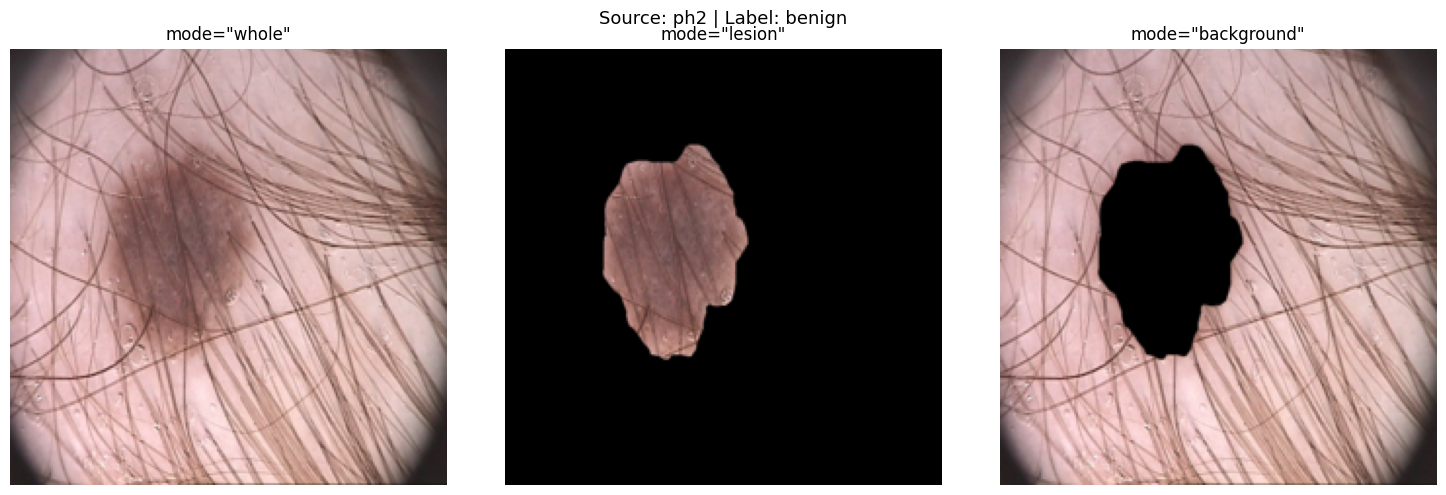

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from pyhealth.processors import DermoscopyImageProcessor

# Pick a sample row from metadata to visualize
sample_row = meta.iloc[0]
img_path  = sample_row["image_path"]
mask_path = sample_row["mask_path"]
label_str = "melanoma" if sample_row["label"] == 1 else "benign"
source    = sample_row["source_dataset"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Source: {source} | Label: {label_str}", fontsize=13)

for ax, mode in zip(axes, ["whole", "lesion", "background"]):
    proc = DermoscopyImageProcessor(mode=mode, normalize=False)
    tensor = proc.process((img_path, mask_path))  # (3, H, W) in [0, 1]
    img_np = tensor.permute(1, 2, 0).numpy()       # (H, W, 3)
    ax.imshow(img_np)
    ax.set_title(f'mode="{mode}"', fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 4: Set Task and Build DataLoaders

The `DermoscopyMelanomaClassification` task maps each image+mask pair to a binary label.
Passing a custom `DermoscopyImageProcessor` allows you to switch modes.

In [8]:
from pyhealth.tasks import DermoscopyMelanomaClassification
from pyhealth.processors import DermoscopyImageProcessor
from pyhealth.datasets import get_dataloader, split_by_sample

task = DermoscopyMelanomaClassification()

# Choose the processing mode — swap this to "lesion" or "background" to compare
image_processor = DermoscopyImageProcessor(
    mode=MODE,
    image_size=224,
    normalize=True,   # ImageNet normalization
)

samples = base_dataset.set_task(
    task=task,
    input_processors={"image": image_processor},
)

print(f"Total samples: {len(samples)}")
print(f"Input schema:  {samples.input_schema}")
print(f"Output schema: {samples.output_schema}")

Setting task DermoscopyMelanomaClassification for dermoscopy base dataset...
Task cache paths: task_df=/Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/task_df.ld, samples=/Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/samples_6e57ccbc-7759-57f2-9a8b-967f71c74a2b.ld
Applying task transformations on data with 1 workers...
Detected Jupyter notebook environment, setting num_workers to 1
Single worker mode, processing sequentially
Worker 0 started processing 200 patients. (Polars threads: 10)


  0%|          | 0/200 [00:00<?, ?it/s]

Rank 0 inferred the following `['bytes']` data format.


100%|██████████| 200/200 [00:00<00:00, 4440.79it/s]

Worker 0 finished processing patients.
Fitting processors on the dataset...


Label melanoma vocab: {0: 0, 1: 1}
Processing samples and saving to /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/samples_6e57ccbc-7759-57f2-9a8b-967f71c74a2b.ld...
Applying processors on data with 1 workers...
Detected Jupyter notebook environment, setting num_workers to 1
Single worker mode, processing sequentially
Worker 0 started processing 200 samples. (0 to 200)


  0%|          | 0/200 [00:00<?, ?it/s]

Rank 0 inferred the following `['tensor', 'no_header_tensor:1']` data format.


100%|██████████| 200/200 [00:01<00:00, 196.65it/s]

Worker 0 finished processing samples.
Cached processed samples to /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/samples_6e57ccbc-7759-57f2-9a8b-967f71c74a2b.ld
Total samples: 200
Input schema:  {'image': 'dermoscopy_image'}
Output schema: {'melanoma': 'binary'}


In [9]:
train_dataset, val_dataset, test_dataset = split_by_sample(samples, [0.7, 0.1, 0.2])

train_loader = get_dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = get_dataloader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = get_dataloader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 140 | Val: 20 | Test: 40


## Step 5: Define the Model

We use `TorchvisionModel` with ResNet50 pretrained on ImageNet — the same architecture used in the
`dermatology_melanoma_classification.py` script from the dermoscopic_artifacts repo.

You can swap `model_name` to any supported architecture:
- `"resnet50"` (default here)
- `"densenet121"` 
- `"vit_b_16"` (Vision Transformer — recommended for ablation study)

### Code Example

```python
# DenseNet121
model = TorchvisionModel(dataset=samples, model_name="densenet121", model_config={"weights": "DEFAULT"})

# Vision Transformer (ViT)
model = TorchvisionModel(dataset=samples, model_name="vit_b_16", model_config={"weights": "DEFAULT"})
```


In [10]:
from pyhealth.models import TorchvisionModel

model = TorchvisionModel(
    dataset=samples,
    model_name="resnet50",
    model_config={"weights": "DEFAULT"},   # ImageNet pretrained weights
)

print(model)

TorchvisionModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

## Step 6: Train the Model

In [11]:
from pyhealth.trainer import Trainer

trainer = Trainer(
    model=model,
    device=DEVICE,
)

trainer.train(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=NUM_EPOCHS,
    optimizer_params={"lr": LEARNING_RATE},
    monitor="roc_auc",
)

TorchvisionModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

Epoch 0 / 1:   0%|          | 0/5 [00:00<?, ?it/s]

--- Train epoch-0, step-5 ---
loss: 0.5944


Evaluation: 100%|██████████| 1/1 [00:00<00:00,  4.49it/s]

--- Eval epoch-0, step-5 ---
pr_auc: 0.3277
roc_auc: 0.5200
f1: 0.0000
loss: 0.5877
New best roc_auc score (0.5200) at epoch-0, step-5


Loaded best model


## Step 7: Evaluate the Model

In [12]:
results = trainer.evaluate(test_loader)
print(f"\n=== Test results (mode='{MODE}') ===")
for metric, value in results.items():
    print(f"  {metric}: {value:.4f}")

Evaluation: 100%|██████████| 2/2 [00:00<00:00,  3.89it/s]


=== Test results (mode='whole') ===
  pr_auc: 0.1467
  roc_auc: 0.3420
  f1: 0.0000
  loss: 0.5530


## Step 8: Compare Modes (Artifact Bias Analysis)

The core research question is: **is the model relying on the lesion or on background artifacts?**

The cell below trains separate models for each mode and compares their AUC. If `background` AUC is
unexpectedly high, it suggests the model has learned spurious correlations from skin artifacts.

> ⚠️ This cell trains 3 full models and may take a while. Reduce `NUM_EPOCHS` or run one mode at a time.

In [13]:
from pyhealth.models import TorchvisionModel
from pyhealth.trainer import Trainer
from pyhealth.datasets import get_dataloader, split_by_sample
from pyhealth.processors import DermoscopyImageProcessor

mode_results = {}

for mode in ["whole", "lesion", "background"]:
    print(f"\n{'='*50}")
    print(f" Training with mode='{mode}'")
    print(f"{'='*50}")

    # Re-process with this mode's processor
    mode_samples = base_dataset.set_task(
        task=DermoscopyMelanomaClassification(),
        input_processors={"image": DermoscopyImageProcessor(mode=mode)},
    )

    tr, va, te = split_by_sample(mode_samples, [0.7, 0.1, 0.2])
    tr_l = get_dataloader(tr, batch_size=BATCH_SIZE, shuffle=True)
    va_l = get_dataloader(va, batch_size=BATCH_SIZE, shuffle=False)
    te_l = get_dataloader(te, batch_size=BATCH_SIZE, shuffle=False)

    m = TorchvisionModel(
        dataset=mode_samples,
        model_name="resnet50",
        model_config={"weights": "DEFAULT"},
    )

    t = Trainer(model=m, device=DEVICE)
    t.train(tr_l, va_l, epochs=NUM_EPOCHS,
            optimizer_params={"lr": LEARNING_RATE}, monitor="roc_auc")

    mode_results[mode] = t.evaluate(te_l)

print("\n" + "="*50)
print(" Mode comparison summary")
print("="*50)
print(f"{'Mode':<15} {'ROC-AUC':>10} {'PR-AUC':>10} {'F1':>8}")
print("-"*45)
for mode, res in mode_results.items():
    roc = res.get("roc_auc", float("nan"))
    pr  = res.get("pr_auc",  float("nan"))
    f1  = res.get("f1",       float("nan"))
    print(f"{mode:<15} {roc:>10.4f} {pr:>10.4f} {f1:>8.4f}")


 Training with mode='whole'
Setting task DermoscopyMelanomaClassification for dermoscopy base dataset...
Task cache paths: task_df=/Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/task_df.ld, samples=/Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/samples_6e57ccbc-7759-57f2-9a8b-967f71c74a2b.ld
Found cached processed samples at /Users/ziquanwang/Documents/UIUC MCS/CS 598 DLH/Project/dermoscopy_data/cache/0b9f4a8f-c7d4-5431-81c7-e21e635caf6e/tasks/DermoscopyMelanomaClassification_9394ad34-bdac-5508-b679-ecd31b3ddfc2/samples_6e57ccbc-7759-57f2-9a8b-967f71c74a2b.ld, skipping processing.
TorchvisionModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=Fal

Epoch 0 / 1:   0%|          | 0/5 [00:00<?, ?it/s]

--- Train epoch-0, step-5 ---
loss: 0.6530


Evaluation: 100%|██████████| 1/1 [00:00<00:00,  8.36it/s]

--- Eval epoch-0, step-5 ---
pr_auc: 0.2796
roc_auc: 0.4048
f1: 0.0000
loss: 0.6440
New best roc_auc score (0.4048) at epoch-0, step-5


...

Evaluation: 100%|██████████| 1/1 [00:00<00:00,  8.00it/s]

--- Eval epoch-0, step-5 ---
pr_auc: 0.5000
roc_auc: 0.9474
f1: 0.0000
loss: 0.4589
New best roc_auc score (0.9474) at epoch-0, step-5


Loaded best model


Evaluation: 100%|██████████| 2/2 [00:00<00:00,  8.51it/s]


 Mode comparison summary
Mode               ROC-AUC     PR-AUC       F1
---------------------------------------------
whole               0.5314     0.1524   0.0000
lesion              0.7852     0.4672   0.0000
background          0.9844     0.9318   0.2222


## Step 9: Per-Dataset Breakdown (Optional)

Run evaluation separately on each source dataset to check cross-dataset generalization.

In [15]:
# Re-use the model trained in Step 6 (mode=MODE)
# Filter test set by source_dataset and evaluate each separately

import torch
from torch.utils.data import Subset

# Read back the metadata to get source labels for each test index
meta_reloaded = pd.read_csv(os.path.join(DATA_ROOT, "dermoscopy-metadata-pyhealth.csv"))

# The split preserves the original ordering, so we can align by index
# NOTE: this assumes split_by_sample uses row-index-aligned splits
print("Evaluating per source dataset on the test split...")
print("(Rerun Step 6 & 7 first if you haven't already)\n")

# Full test eval for reference
full_results = trainer.evaluate(test_loader)
print(f"Full test set  | ROC-AUC: {full_results.get('roc_auc', 'N/A'):.4f}")

Evaluating per source dataset on the test split...
(Rerun Step 6 & 7 first if you haven't already)



Evaluation: 100%|██████████| 2/2 [00:01<00:00,  1.67it/s]

Full test set  | ROC-AUC: 0.3420
